# Unsupervised Learning — Clustering

## Supervised vs. Unsupervised

```
Supervised:    Labels vorhanden → Modell lernt anhand von Beispielen
Unsupervised:  KEINE Labels → Modell findet selbst Strukturen
```

**Anwendungen:** Kundensegmentierung, Anomalie-Erkennung, Genanalyse, Empfehlungssysteme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs, load_wine

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

## Beispieldaten erstellen

`make_blobs` erstellt künstliche Cluster-Daten zum Üben.

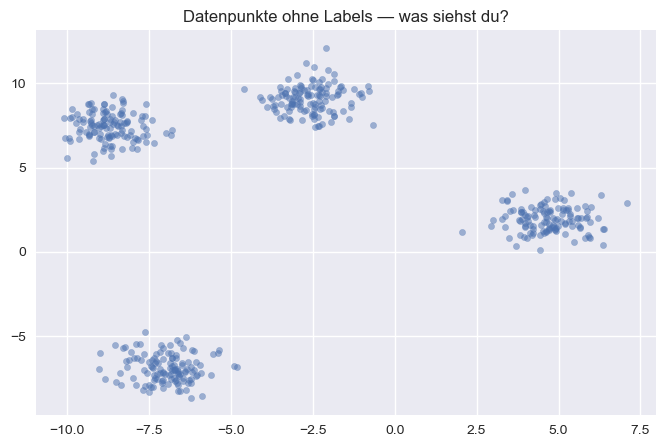

Datenpunkte: 500 | Features: 2


In [2]:
# Künstliche Daten mit 4 Clustern
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.8, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, s=20)
plt.title('Datenpunkte ohne Labels — was siehst du?')
plt.show()

print(f"Datenpunkte: {X.shape[0]} | Features: {X.shape[1]}")

## K-Means Clustering

### Algorithmus:
```
1. K Centroids zufällig platzieren
2. Jeden Punkt dem nächsten Centroid zuordnen
3. Centroids neu berechnen (Mittelpunkt)
4. Wiederholen bis keine Änderung mehr
```

Inertia: 607.29
Cluster-Größen: [125 125 125 125]


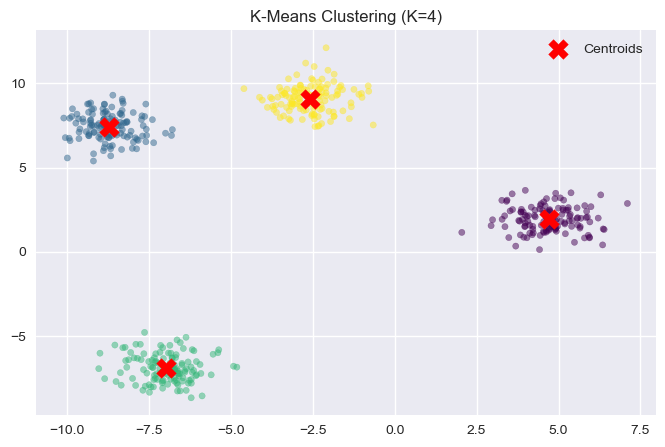

In [3]:
# K-Means mit K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

labels = kmeans.labels_               # Cluster-Zuweisung pro Punkt
centroids = kmeans.cluster_centers_   # Koordinaten der Centroids
inertia = kmeans.inertia_             # Güte (niedriger = besser)

print(f"Inertia: {inertia:.2f}")
print(f"Cluster-Größen: {np.bincount(labels)}")

# Visualisierung
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.5, s=20)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering (K=4)')
plt.legend()
plt.show()

## Die Elbow Method — Optimales K finden

Da wir K nicht immer kennen, nutzen wir die Elbow Method:
- Teste verschiedene K-Werte
- Plotte Inertia gegen K
- Der "Knick" im Graph = optimales K

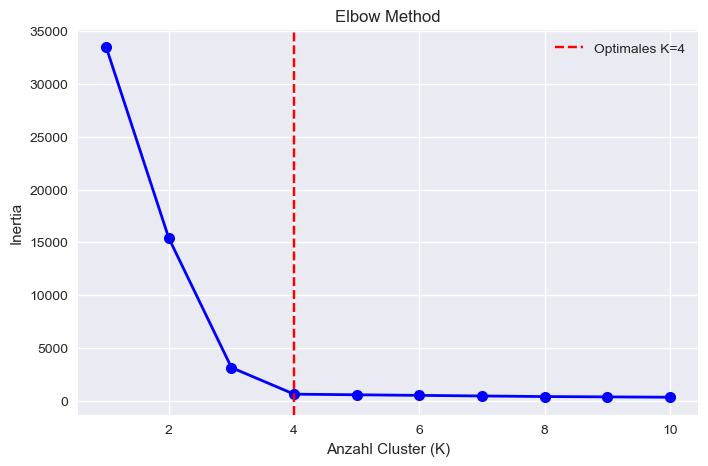

In [4]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=4, color='red', linestyle='--', label='Optimales K=4')
plt.xlabel('Anzahl Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.legend()
plt.show()

## Silhouette Score — Bessere Evaluation

```
Silhouette Score = (b - a) / max(a, b)

a = mittlerer Abstand zum eigenen Cluster
b = mittlerer Abstand zum nächsten fremden Cluster

Bereich: -1 bis +1  →  je höher, desto besser!
```

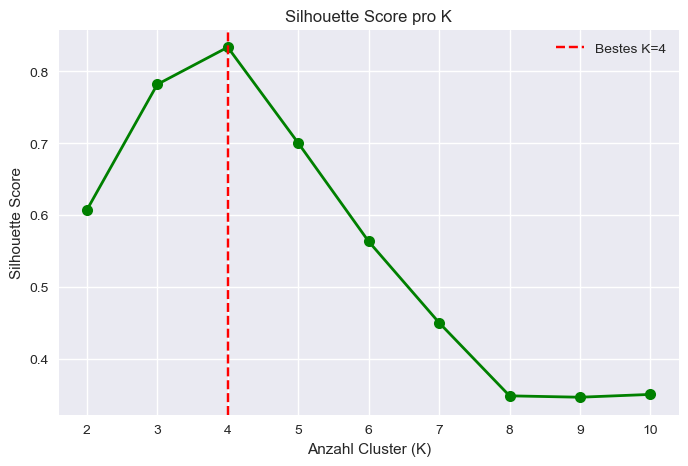

Bestes K laut Silhouette: 4


In [5]:
silhouette_scores = []
K_range = range(2, 11)  # Silhouette braucht mindestens K=2

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Bestes K={best_k}')
plt.xlabel('Anzahl Cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score pro K')
plt.legend()
plt.show()

print(f"Bestes K laut Silhouette: {best_k}")

## DBSCAN — Dichte-basiertes Clustering

```
Core Point:   > min_samples Nachbarn innerhalb von eps
Border Point: Nachbar eines Core Points, aber zu wenig eigene Nachbarn
Noise Point:  Ausreißer → Label = -1
```

**Vorteil:** Kein K nötig, findet Ausreißer automatisch!

Gefundene Cluster: 2
Ausreißer (Noise): 0


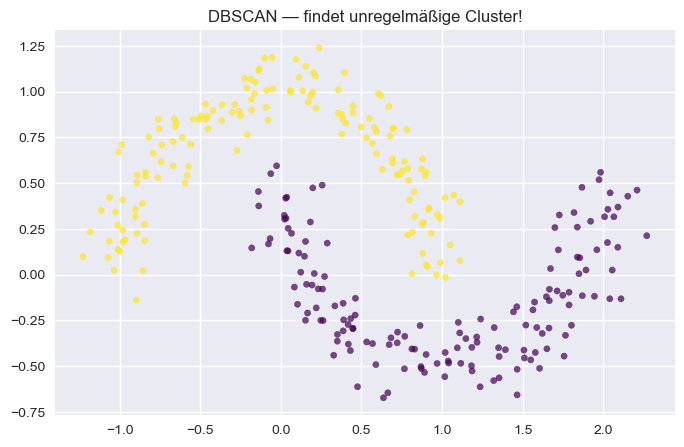

In [6]:
# Daten mit Ausreißern und unregelmäßigen Formen
from sklearn.datasets import make_moons
X_moon, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

# DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_moon)

n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = list(labels_dbscan).count(-1)

print(f"Gefundene Cluster: {n_clusters}")
print(f"Ausreißer (Noise): {n_noise}")

plt.figure(figsize=(8, 5))
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=labels_dbscan, cmap='viridis', s=20, alpha=0.7)
plt.title('DBSCAN — findet unregelmäßige Cluster!')
plt.show()

## Gaussian Mixture Model (GMM) — Soft Clustering

```
K-Means (Hard):  Punkt gehört EINEM Cluster — 100%
GMM (Soft):      Punkt gehört JEDEM Cluster mit Wahrscheinlichkeit
                 z.B. [0.7, 0.2, 0.1] für 3 Cluster
```

Beispiel Wahrscheinlichkeiten (erste 3 Punkte):
[[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]]


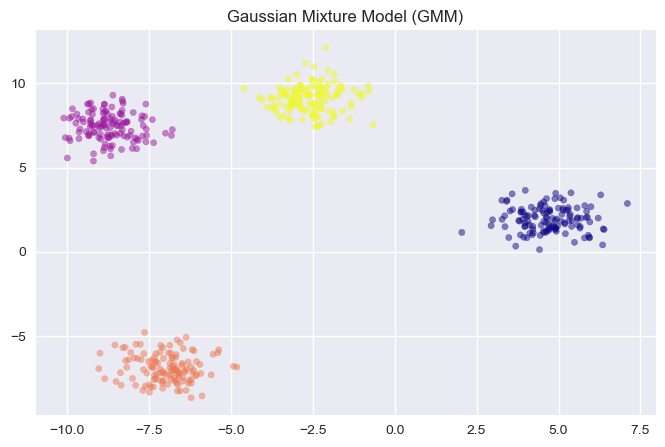

In [7]:
# GMM auf den blob-Daten
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.8, random_state=42)

gmm = GaussianMixture(n_components=4, random_state=42)
gmm.fit(X)

labels_gmm = gmm.predict(X)           # harte Zuweisung
probs = gmm.predict_proba(X)          # weiche Wahrscheinlichkeiten

print("Beispiel Wahrscheinlichkeiten (erste 3 Punkte):")
print(probs[:3].round(3))

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_gmm, cmap='plasma', alpha=0.5, s=20)
plt.title('Gaussian Mixture Model (GMM)')
plt.show()

## Reales Beispiel: Wine Dataset

In [8]:
# Wine Dataset laden
wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

print(f"Shape: {X_wine.shape}")
print(f"Features: {list(wine.feature_names)}")
X_wine.head()

Shape: (178, 13)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [9]:
# WICHTIG: Skalieren vor dem Clustering!
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

# K-Means mit K=3 (3 Weinsorten im Dataset)
kmeans_wine = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_wine = kmeans_wine.fit_predict(X_wine_scaled)

print(f"Cluster-Größen: {np.bincount(labels_wine)}")
print(f"Silhouette Score: {silhouette_score(X_wine_scaled, labels_wine):.4f}")

# Cluster-Eigenschaften
X_wine['cluster'] = labels_wine
X_wine.groupby('cluster')[['alcohol', 'flavanoids', 'color_intensity']].mean().round(2)

Cluster-Größen: [65 51 62]
Silhouette Score: 0.2849


,alcohol,flavanoids,color_intensity
cluster,,,
0,12.25,2.05,2.97
1,13.13,0.82,7.23
2,13.68,3.00,5.45


## Vergleich: K-Means vs. DBSCAN vs. GMM

| Methode | Braucht K? | Ausreißer? | Cluster-Form | Soft? |
|---------|------------|------------|--------------|-------|
| **K-Means** | Ja | Nein | Rund | Nein |
| **DBSCAN** | Nein | Ja | Beliebig | Nein |
| **GMM** | Ja | Nein | Elliptisch | Ja |
| **Hierarchical** | Nein* | Nein | Beliebig | Nein |

*Dendrogram zeigt alle K-Werte gleichzeitig